## Iris Flower Classification with Decision Tree - Supervised Learning

> Tugas ini bertujuan untuk membangun model klasifikasi bunga Iris berdasarkan fitur - fitur fisik yang ada pada bunga Iris. Dataset sudah tersedia di Scikit Learn Datasets dan bisa diimpor langsung lewat ```sklearn.datasets```

> Referensi : https://colab.research.google.com/drive/1ZcRJnyah-XppyYf9B7JWrEtsVHJCZ5y_?usp=sharing

Nama: Nicholas Kisu Candra

Program: AI Development

### 1. Import module yang diperlukan

In [1]:
# TODO: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris # Dataset bunga iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### 2. Data collection

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Optional: map target to actual class names
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### TODO #1 :

> Isi insight, coba cari tahu apa itu "sepal length, sepal width, petal length, petal width" pada bunga iris.

Sepal (daun kelopak): bagian terluar dari sebuah bunga (kebanyakan hijau dan mirip daun) yang menutupi kuncup 
Petal: bagian paling atas bunga yang seringkali berwarna

[https://www.amnh.org/learn-teach/curriculum-collections/biodiversity-counts/plant-identification/plant-morphology/parts-of-a-flower]


1. Sepal length: panjang sebuah sepal
2. Sepal width: lebar sebuah sepal
3. Petal length: panjang sebuah petal
4. Petal width: lebar sebuah petal

Iris Dataset terdiri dari tiga spesies bunga yang berbeda: Iris setosa, Iris versicolor, dan Iris virginica. Setiap spesies mempunya 
Keempat fitur ini merepresentasikan karakteristik fisik bunga yang dapat digunakan untuk membedakan spesies. Setiap spesies Iris memiliki pola ukuran yang berbeda:
1. Iris setosa umumnya memiliki ukuran petal yang lebih kecil dibandingkan spesies lainnya. 
2. Iris versicolor memiliki ukuran yang berada di tengah, 
3. sedangkan Iris virginica cenderung memiliki ukuran petal dan sepal yang lebih besar.

Oleh karena itu, dataset ini sering digunakan dalam machine learning untuk membangun model klasifikasi yang dapat memprediksi spesies bunga berdasarkan ukuran sepal dan petal yang diberikan.

[https://www.geeksforgeeks.org/machine-learning/iris-dataset/]

### 3. Exploratory Data Analysis

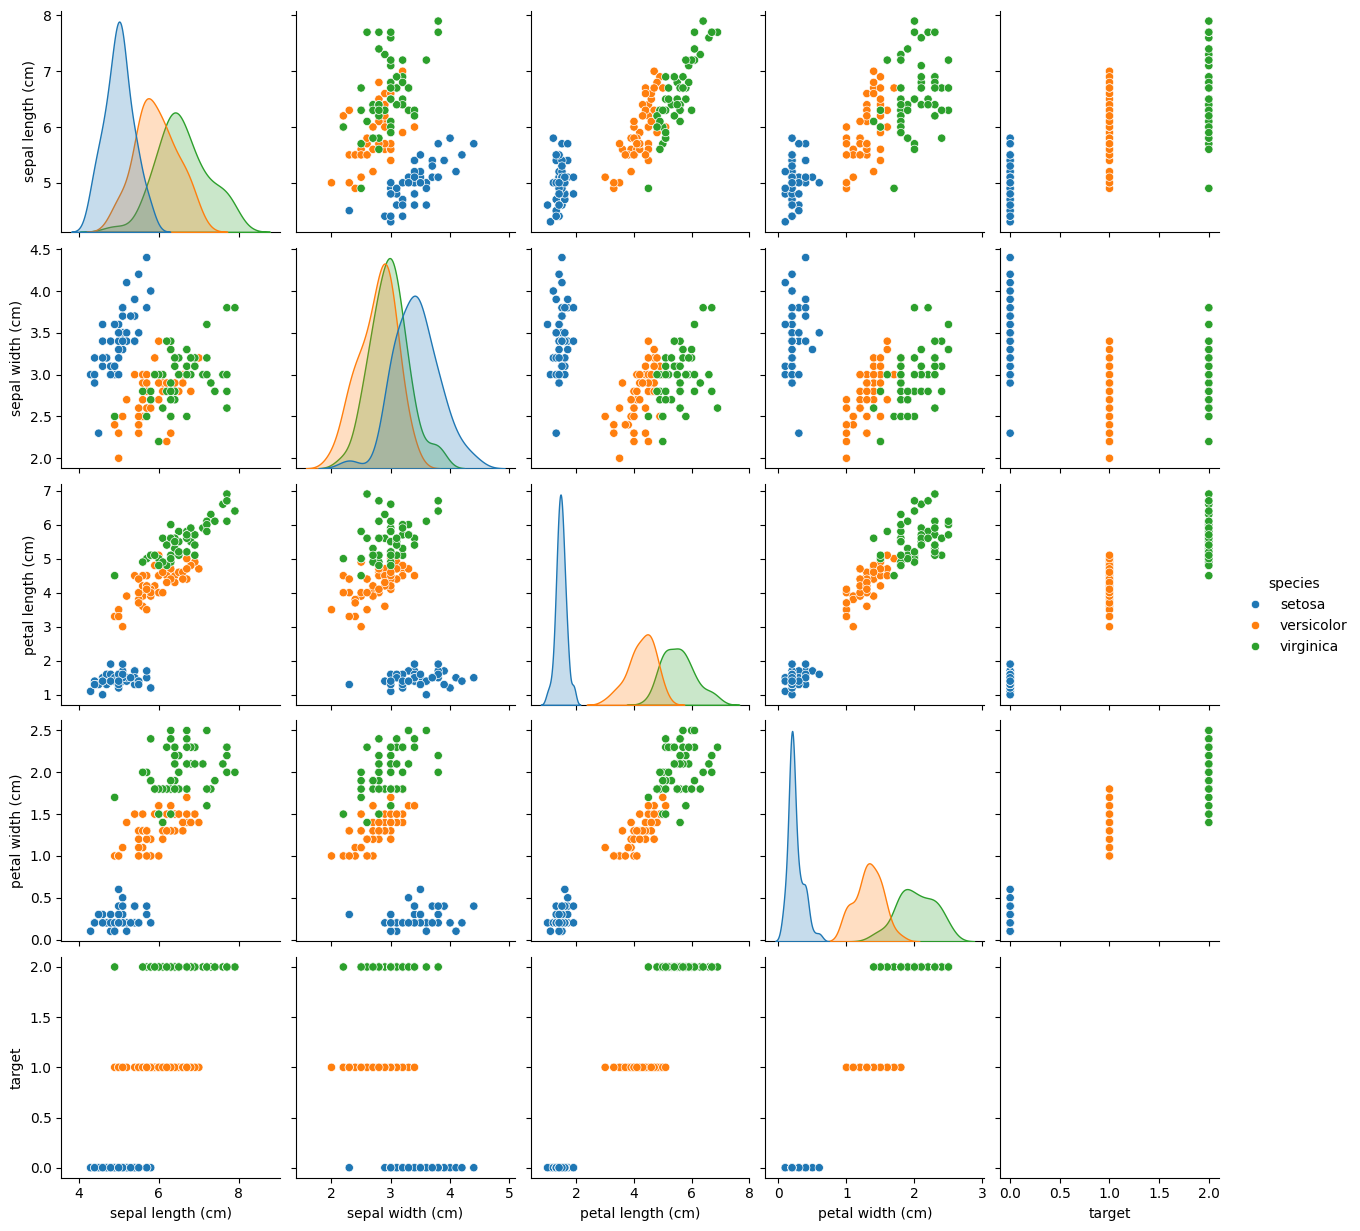

In [3]:
# TODO: Plot distribution
sns.pairplot(df, hue="species")
plt.show()

### 4. Split Data


In [5]:
# TODO: Split data into training and testing
X = df[iris.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 5. Model Initialization

In [6]:
# TODO: Initialize Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)

### 6. Model Training

In [7]:
# TODO: Train the model using training data
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

### TODO #2 :

> Isi insight, kenapa menggunakan Decision Tree? Apakah ada algoritma lain yang serupa?

Decision Tree digunakan karena mampu memodelkan hubungan non-linear dengan cara membagi data berdasarkan aturan tertentu pada fitur. Pada dataset Iris, terlihat bahwa beberapa fitur seperti petal length dan petal width memiliki batas yang cukup jelas dalam memisahkan spesies bunga. Dengan demikian, Decision Tree dapat dengan mudah menemukan aturan pemisahan tersebut tanpa memerlukan transformasi data yang kompleks.

### 7. Evaluation

In [8]:
# TODO: Evaluate model performance
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### TODO #3 :

> Isi insight, analisis hasil *confusion matrix* ini, apakah ini disebut sebagai overfitting?

Berdasarkan confusion matrix, seluruh data pada test set berhasil diklasifikasikan dengan benar tanpa adanya kesalahan prediksi. Hal ini terlihat dari nilai pada diagonal utama yang menunjukkan jumlah prediksi yang tepat untuk setiap kelas, serta tidak adanya nilai di luar diagonal.

Meskipun akurasi mencapai 100%, hal ini tidak selalu menunjukkan overfitting. Pada dataset Iris, kelas-kelas memiliki pemisahan yang cukup jelas, terutama pada fitur petal length dan petal width, sehingga model dapat dengan mudah menemukan aturan klasifikasi yang tepat. Oleh karena itu, performa yang tinggi ini lebih disebabkan oleh karakteristik dataset yang memang mudah dipisahkan, bukan semata-mata karena overfitting.

### 8. Visualization

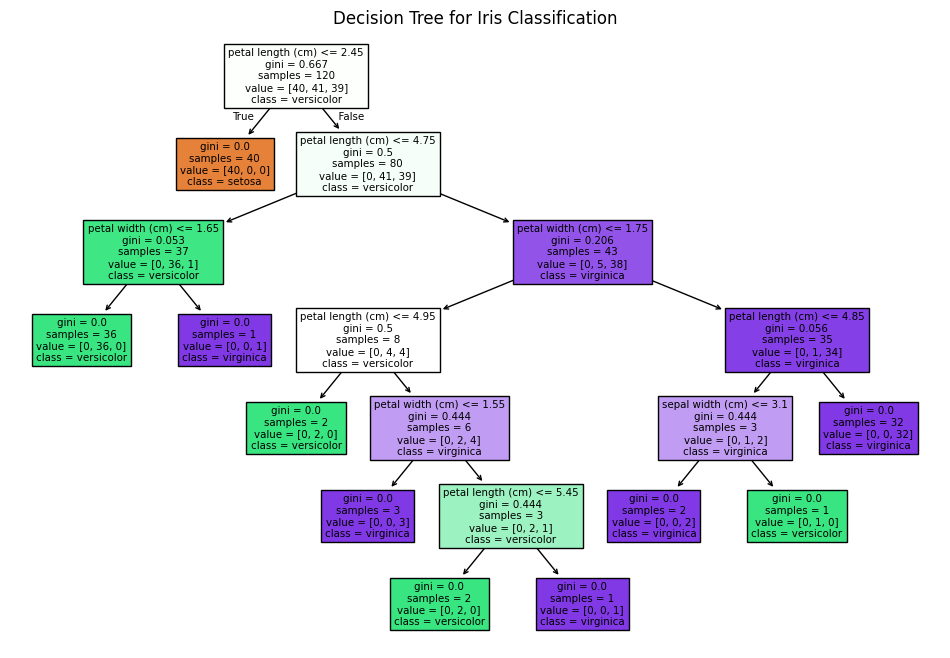

In [9]:
# TODO: Visualize the Decision Tree
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Decision Tree for Iris Classification")
plt.show()


### TODO #4 :

> Isi insight, berikan penjelasan cara kerja dari Decision Tree berdasarkan output diatas.

Decision Tree bekerja dengan membagi data secara bertahap berdasarkan kondisi tertentu pada fitur, mirip seperti struktur if-else yang bercabang. Setiap node pada tree merepresentasikan sebuah kondisi, misalnya petal length <= 2.45, yang digunakan untuk memisahkan data ke dalam cabang kiri atau kanan.

Pemilihan kondisi tersebut didasarkan pada nilai impurity seperti `gini`, di mana model berusaha memisahkan data agar setiap cabang memiliki kelas yang sehomogen mungkin. Nilai `gini` yang mendekati 0 menunjukkan bahwa data dalam node tersebut sudah hampir seluruhnya berasal dari satu kelas.

Proses ini berlanjut hingga mencapai leaf node, yaitu node akhir yang digunakan sebagai hasil prediksi. Berdasarkan visualisasi, fitur petal length dan petal width memiliki peran penting dalam memisahkan spesies bunga, karena sering digunakan sebagai dasar pembagian pada tree.

### 9. Prediction

In [10]:
# predict new data
def predict_iris(sample):
    pred_class = model.predict([sample])[0]
    return iris.target_names[pred_class]

# Example:
example = [5.1, 3.5, 1.4, 0.2] # "sepal length, sepal width, petal length, petal width"
print("Predicted class:", predict_iris(example))

Predicted class: setosa


/home/nick/github_repo/tugas_python_ai_b10/tugas-10/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [12]:
print(predict_iris([5.1, 3.5, 1.4, 0.2]))
print(predict_iris([6.0, 2.9, 4.5, 1.5]))
print(predict_iris([6.5, 3.0, 5.5, 2.0]))

setosa
versicolor
virginica


/home/nick/github_repo/tugas_python_ai_b10/tugas-10/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/nick/github_repo/tugas_python_ai_b10/tugas-10/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/nick/github_repo/tugas_python_ai_b10/tugas-10/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### TODO #5 :

> Isi insight, berikan beberapa kali percobaan untuk mengklasifikasikan beberapa spesies bunga Iris berbeda berdasarkan "sepal length, sepal width, petal length, petal width".

Berdasarkan beberapa percobaan prediksi menggunakan data input yang berbeda, model mampu mengklasifikasikan spesies bunga dengan tepat sesuai karakteristiknya. Data dengan nilai petal length dan petal width yang kecil cenderung diklasifikasikan sebagai Iris setosa. Sementara itu, nilai yang berada di tengah diklasifikasikan sebagai Iris versicolor, dan nilai yang lebih besar cenderung diklasifikasikan sebagai Iris virginica. Hal ini menunjukkan bahwa fitur petal length dan petal width memiliki pengaruh yang signifikan dalam menentukan klasifikasi spesies bunga.